In [32]:
from pystac_client import Client
import lazycogs
import stac_geoparquet
from pyproj import Transformer
from IPython.display import JSON

In [2]:
cdse_stac = Client.open("https://stac.dataspace.copernicus.eu/v1/")

In [3]:
s1_items = csde_stac.search(
    collections="sentinel-1-global-mosaics",
    bbox=[-122, 45, -121.99, 45.01], # arbitrary
    datetime="2026-04",
    limit=1
).item_collection().to_dict()

In [5]:
s1_items_dict = s1_items.to_dict()

In [8]:
for item in s1_items_dict["features"]:
    item["properties"].pop("created", None)
    item["properties"].pop("expires", None)
    item["properties"].pop("updated", None)
    item["properties"].pop("published", None)
    item["properties"].pop("end_datetime", None)
    item["properties"].pop("start_datetime", None)
    item["properties"].pop("eopf:origin_datetime", None)

In [9]:
s1_items_dict["features"][0]["properties"]

{'gsd': 20,
 '_private': {'visible': True,
  'product_name': 'Sentinel-1_IW_mosaic_2026_M04_10TEQ_0_0',
  'product_size': 213683797,
  'product_uuid': '449c2a00-7aac-43c7-8ed0-ba776bed0d48'},
 'datetime': '2026-04-01T00:00:00Z',
 'grid:code': 'MGRS-10TEQ',
 'instruments': ['sar'],
 'auth:schemes': {'s3': {'type': 's3'},
  'oidc': {'type': 'openIdConnect',
   'openIdConnectUrl': 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/.well-known/openid-configuration'}},
 'product:type': 'S1SAR_L3_IW_MCM',
 'constellation': 'sentinel-1',
 'storage:schemes': {'cdse-s3': {'type': 'custom-s3',
   'class': 'hot',
   'title': 'Copernicus Data Space Ecosystem S3',
   'platform': 'https://eodata.dataspace.copernicus.eu',
   'description': 'This endpoint provides access to EO data which is stored on the object storage of both CloudFerro Cloud and OpenTelekom Cloud (OTC). See the [documentation](https://documentation.dataspace.copernicus.eu/APIs/S3.html) for more information, including how to 

Make sure we are only looking at one tile, implying a constant projection

In [10]:
tiles = set([f["properties"]["grid:code"] for f in s1_items_dict["features"]])
assert(len(tiles) == 1)

In [11]:
stac_geoparquet.to_geodataframe(s1_items_dict["features"], dtype_backend="numpy_nullable").to_parquet("/tmp/s1_items.parquet")

In [12]:
parquet_reopen = gpd.read_parquet("/tmp/s1_items.parquet")

In [13]:
parquet_reopen.iloc[0]

type                                                              Feature
stac_version                                                        1.1.0
stac_extensions         [https://cs-si.github.io/eopf-stac-extension/v...
id                                Sentinel-1_IW_mosaic_2026_M04_10TEQ_0_0
geometry                POLYGON ((-123.0002505235858 44.25287739310456...
bbox                    [-123.0002544396381, 44.24600263463746, -121.7...
links                   [{'href': 'https://stac.dataspace.copernicus.e...
assets                  {'HH': None, 'HV': None, 'Product': {'auth:ref...
collection                                      sentinel-1-global-mosaics
gsd                                                                    20
_private                {'product_name': 'Sentinel-1_IW_mosaic_2026_M0...
datetime                                        2026-04-01 00:00:00+00:00
grid:code                                                      MGRS-10TEQ
instruments                           

Set up S3 credentials

In [14]:
import configparser

config = configparser.ConfigParser()
config.read("/home/jovyan/.s3cfg")

access_key = config.get("csde", "access_key")
secret_key = config.get("csde", "secret_key")

store = obstore.store.S3Store(
    aws_access_key_id=access_key,
    aws_secret_access_key=secret_key,
    bucket="eodata",
    endpoint="https://eodata.dataspace.copernicus.eu"
)

In [15]:
ex_feat = s1_items_dict["features"][0]

In [16]:
ex_feat

{'type': 'Feature',
 'stac_version': '1.1.0',
 'stac_extensions': ['https://cs-si.github.io/eopf-stac-extension/v1.2.0/schema.json',
  'https://stac-extensions.github.io/alternate-assets/v1.2.0/schema.json',
  'https://stac-extensions.github.io/authentication/v1.1.0/schema.json',
  'https://stac-extensions.github.io/file/v2.1.0/schema.json',
  'https://stac-extensions.github.io/grid/v1.1.0/schema.json',
  'https://stac-extensions.github.io/processing/v1.2.0/schema.json',
  'https://stac-extensions.github.io/product/v1.0.0/schema.json',
  'https://stac-extensions.github.io/projection/v2.0.0/schema.json',
  'https://stac-extensions.github.io/sar/v1.3.0/schema.json',
  'https://stac-extensions.github.io/storage/v2.0.0/schema.json',
  'https://stac-extensions.github.io/timestamps/v1.1.0/schema.json'],
 'id': 'Sentinel-1_IW_mosaic_2026_M04_10TEQ_0_0',
 'geometry': {'type': 'Polygon',
  'coordinates': [[[-123.0002505235858, 44.25287739310456],
    [-121.74677928567317, 44.24600263463746],
  

In [17]:
ex_feat["bbox"]

[-123.0002544396381, 44.24600263463746, -121.72719599646072, 45.15383724945129]

In [18]:
ex_feat["assets"]["VH"]

{'href': 's3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2026/04/01/Sentinel-1_IW_mosaic_2026_M04_10TEQ_0_0/VH.tif',
 'type': 'image/tiff; application=geotiff; profile=cloud-optimized',
 'title': 'VH: Vertical transmit, horizontal receive',
 'description': 'Amplitude of vertically polarized signal received horizontally.',
 'alternate': {'https': {'href': 'https://download.dataspace.copernicus.eu/odata/v1/Products(449c2a00-7aac-43c7-8ed0-ba776bed0d48)/Nodes(Sentinel-1_IW_mosaic_2026_M04_10TEQ_0_0)/Nodes(VH.tif)/$value',
   'auth:refs': ['oidc'],
   'storage:refs': [],
   'alternate:name': 'HTTPS'}},
 'auth:refs': ['s3'],
 'file:size': 106874194,
 'proj:code': 'EPSG:32610',
 'proj:shape': [5004, 5004],
 'storage:refs': ['cdse-s3', 'creodias-s3'],
 'proj:transform': [20.0, 0.0, 499980.0, 0.0, -20.0, 5000040.0],
 'file:local_path': 'Sentinel-1_IW_mosaic_2026_M04_10TEQ_0_0/VH.tif',
 'nodata': -32768,
 'data_type': 'float32',
 'alternate:name': 'S3',
 'sar:polarizations': ['VH'],
 'ro

In [19]:
from pyproj import Transformer

dst_crs = ex_feat["assets"]["VH"]["proj:code"]

transformer = Transformer.from_crs("epsg:4326", dst_crs, always_xy=True)
dst_bbox = lazycogs.align_bbox(
    affine=ex_feat["assets"]["VH"]["proj:transform"],
    bbox=transformer.transform_bounds(*ex_feat["bbox"]),
)
print(dst_bbox)

(499960.0, 4899180.0, 601640.0, 5000840.0)


In [20]:
import logging
logging.getLogger("lazycogs").setLevel(logging.DEBUG)

In [21]:
target_assets = ["VV", "VH"]

da = lazycogs.open(
    "/tmp/s1_items.parquet",
    store=store,
    bbox=dst_bbox,
    crs=ex_feat["assets"]["VH"]["proj:code"],
    resolution=ex_feat["properties"]["gsd"],
    bands=target_assets,
    ids=[ex_feat["id"]]
)

DEBUG:lazycogs._core:_inspect_first_item took 1.374s, found 2 bands
DEBUG:lazycogs._core:_build_time_steps: Arrow table has 1 rows
DEBUG:lazycogs._core:_build_time_steps took 0.013s, found 1 time steps
INFO:lazycogs._core:Discovered 2 bands and 1 time steps.
DEBUG:lazycogs._backend:duckdb_client.search bands=['VV', 'VH'] datetime=2026-04-01 returned 1 items in 0.021s


In [22]:
da = da.load()

DEBUG:lazycogs._backend:read_chunk_async bands=['VV', 'VH'] datetime=2026-04-01 (1 items, 5084x5083 px) took 9.705s


In [23]:
(da == -32768).all()

<xarray.DataArray ()> Size: 1B
array(False)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    grid_mapping:            spatial_ref
    zarr_conventions:        [{'schema_url': 'https://raw.githubusercontent.c...
    spatial:dimensions:      ['y', 'x']
    spatial:bbox:            (499960.0, 4899180.0, 601640.0, 5000840.0)
    spatial:transform_type:  affine
    spatial:transform:       [20.0, 0.0, 499960.0, 0.0, -20.0, 5000840.0]
    spatial:shape:           [5083, 5084]
    spatial:registration:    pixel
    proj:code:               EPSG:32610
    _FillValue:              -32768.0

In [24]:
da = da.where(da != -32768)

In [27]:
da_coarse = da.coarsen(x=10, y=10, boundary="trim").mean()

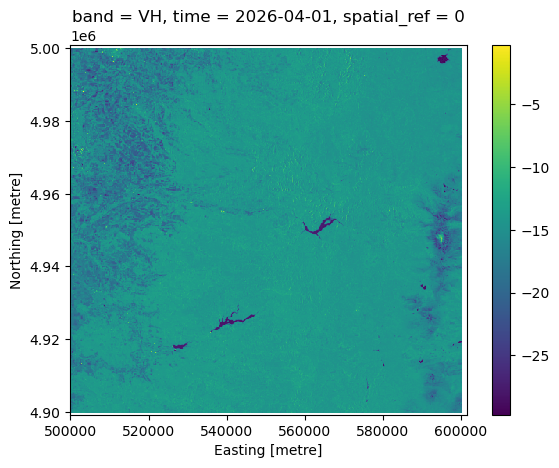

In [31]:
(10 * np.log10(da_coarse)).sel(band="VH").plot()